# Experiment Results

Visualizes architecture synthesis experiment metrics from `.stats` and `.statscompare` files.
Data is auto-discovered under `code/data/final` (or `data/final`).

Run from the `code/` directory: `uv run jupyter notebook notebooks/experiment_results.ipynb`

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "notebooks":
    sys.path.insert(0, str(NOTEBOOK_DIR))
elif (NOTEBOOK_DIR / "notebooks").is_dir():
    sys.path.insert(0, str(NOTEBOOK_DIR / "notebooks"))
else:
    for parent in NOTEBOOK_DIR.parents:
        candidate = parent / "code" / "notebooks"
        if candidate.is_dir():
            sys.path.insert(0, str(candidate))
            break

from _experiment_viz import (
    MetricSection,
    all_required_metrics,
    apply_labels,
    discover_data_dir,
    load_all_results,
    render_comparison_summary,
    render_section,
    setup_style,
)
from IPython.display import display

SHORT_LABELS: dict[str, str] = {
    "add": "ADD",
    "pps": "PPS",
    "pp": "PP",
    "EventTicketSystem": "ETS",
    "HotelPricingSystem": "HPS",
    "eShop": "eShop",
    "pitstop": "Pitstop",
}

METRIC_SECTIONS: list[MetricSection] = [
    {
        "title": "Average Dependency Degree",
        "metrics": ["dep_avg"],
        "ylabel": "Avg Dep Degree",
    },
    {
        "title": "Average Change Impact",
        "metrics": ["average_change_impact"],
        "ylabel": "Avg Change Impact",
    },
    {
        "title": "Node Recall, Precision, F1",
        "metrics": ["node_recall", "node_precision", "node_f1"],
        "ylabel": "Score",
    },
    {
        "title": "Edge Recall, Precision, F1",
        "metrics": ["edge_recall", "edge_precision", "edge_f1"],
        "ylabel": "Score",
    },
]

In [2]:
data_dir = discover_data_dir()
required = all_required_metrics(METRIC_SECTIONS)
df = load_all_results(data_dir, required)
df = apply_labels(df, SHORT_LABELS)
display(df.head())

,method,app,dep_avg,average_change_impact,node_precision,node_recall,node_f1,edge_precision,edge_recall,edge_f1,base_node_count,generated_node_count,common_node_count,base_edge_count,generated_edge_count,common_edge_count,method_label,app_label
0,add,EventTicketSystem,1.571429,0.280612,0.857143,0.923077,0.888889,0.795455,0.603448,0.686275,26,28,24,58,44,35,ADD,ETS
1,add,HotelPricingSystem,1.578947,0.299169,0.842105,0.800000,0.820513,0.533333,0.615385,0.571429,20,19,16,26,30,16,ADD,HPS
2,add,eShop,1.066667,0.248889,0.666667,0.526316,0.588235,0.187500,0.120000,0.146341,19,15,10,25,16,3,ADD,eShop
3,add,marketplace,1.142857,0.147392,0.428571,0.818182,0.562500,0.166667,0.333333,0.222222,11,21,9,12,24,4,ADD,Marketplace
4,add,pitstop,1.550000,0.255000,0.950000,0.950000,0.950000,0.612903,0.904762,0.730769,20,20,19,21,31,19,ADD,Pitstop


## Comparison Summary (Mean over Apps / Methods)

### By Method — mean over apps

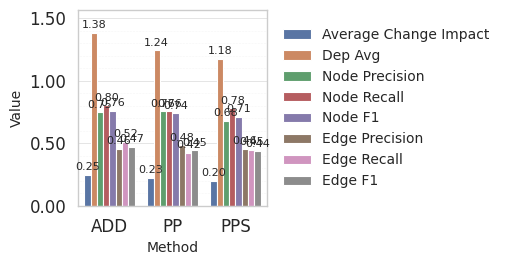

**Comparison — By Method (Mean over Apps)**

,Method,Average Change Impact,Dep Avg,Node Precision,Node Recall,Node F1,Edge Precision,Edge Recall,Edge F1
0,ADD,0.246,1.382,0.749,0.804,0.762,0.459,0.515,0.471
1,PP,0.226,1.243,0.756,0.757,0.740,0.484,0.423,0.445
2,PPS,0.202,1.176,0.678,0.781,0.713,0.456,0.447,0.437


\begin{tabular}{llrrrrrrrr}
\toprule
 & Method & Average Change Impact & Dep Avg & Node Precision & Node Recall & Node F1 & Edge Precision & Edge Recall & Edge F1 \\
\midrule
0 & ADD & 0.246 & 1.382 & 0.749 & 0.804 & 0.762 & 0.459 & 0.515 & 0.471 \\
1 & PP & 0.226 & 1.243 & 0.756 & 0.757 & 0.740 & 0.484 & 0.423 & 0.445 \\
2 & PPS & 0.202 & 1.176 & 0.678 & 0.781 & 0.713 & 0.456 & 0.447 & 0.437 \\
\bottomrule
\end{tabular}



### By App — mean over methods

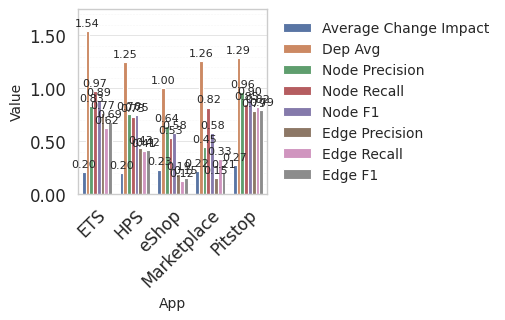

**Comparison — By App (Mean over Methods)**

,App,Average Change Impact,Dep Avg,Node Precision,Node Recall,Node F1,Edge Precision,Edge Recall,Edge F1
0,ETS,0.205,1.540,0.829,0.974,0.892,0.766,0.621,0.685
1,HPS,0.196,1.245,0.759,0.733,0.746,0.432,0.410,0.417
2,eShop,0.232,1.004,0.640,0.526,0.576,0.193,0.120,0.148
3,Marketplace,0.220,1.259,0.445,0.818,0.576,0.155,0.333,0.210
4,Pitstop,0.272,1.287,0.965,0.850,0.901,0.786,0.825,0.794


\begin{tabular}{llrrrrrrrr}
\toprule
 & App & Average Change Impact & Dep Avg & Node Precision & Node Recall & Node F1 & Edge Precision & Edge Recall & Edge F1 \\
\midrule
0 & ETS & 0.205 & 1.540 & 0.829 & 0.974 & 0.892 & 0.766 & 0.621 & 0.685 \\
1 & HPS & 0.196 & 1.245 & 0.759 & 0.733 & 0.746 & 0.432 & 0.410 & 0.417 \\
2 & eShop & 0.232 & 1.004 & 0.640 & 0.526 & 0.576 & 0.193 & 0.120 & 0.148 \\
3 & Marketplace & 0.220 & 1.259 & 0.445 & 0.818 & 0.576 & 0.155 & 0.333 & 0.210 \\
4 & Pitstop & 0.272 & 1.287 & 0.965 & 0.850 & 0.901 & 0.786 & 0.825 & 0.794 \\
\bottomrule
\end{tabular}



In [3]:
setup_style()
render_comparison_summary(df, SHORT_LABELS)

## Average Dependency Degree

### By Method

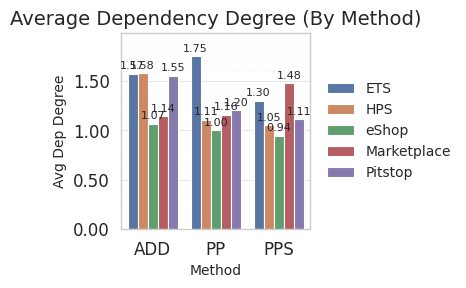

**Average Dependency Degree — By Method (Aggregated)**

App,ETS,HPS,Marketplace,Pitstop,eShop
Method,,,,,
ADD,1.571,1.579,1.143,1.550,1.067
PP,1.750,1.105,1.158,1.200,1.000
PPS,1.297,1.050,1.476,1.111,0.944


\begin{tabular}{lrrrrr}
\toprule
App & ETS & HPS & Marketplace & Pitstop & eShop \\
Method &  &  &  &  &  \\
\midrule
ADD & 1.571 & 1.579 & 1.143 & 1.550 & 1.067 \\
PP & 1.750 & 1.105 & 1.158 & 1.200 & 1.000 \\
PPS & 1.297 & 1.050 & 1.476 & 1.111 & 0.944 \\
\bottomrule
\end{tabular}



### By App

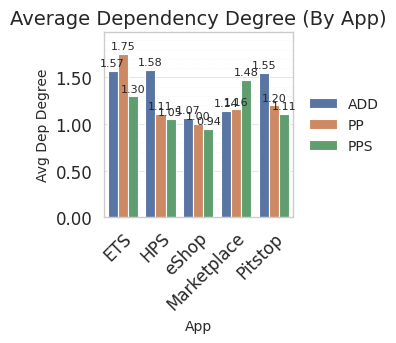

**Average Dependency Degree — By App (Aggregated)**

Method,ADD,PP,PPS
App,,,
ETS,1.571,1.750,1.297
HPS,1.579,1.105,1.050
Marketplace,1.143,1.158,1.476
Pitstop,1.550,1.200,1.111
eShop,1.067,1.000,0.944


\begin{tabular}{lrrr}
\toprule
Method & ADD & PP & PPS \\
App &  &  &  \\
\midrule
ETS & 1.571 & 1.750 & 1.297 \\
HPS & 1.579 & 1.105 & 1.050 \\
Marketplace & 1.143 & 1.158 & 1.476 \\
Pitstop & 1.550 & 1.200 & 1.111 \\
eShop & 1.067 & 1.000 & 0.944 \\
\bottomrule
\end{tabular}



**Average Dependency Degree — Unaggregated**

,Method,App,Dep Avg
0,ADD,ETS,1.571
1,ADD,HPS,1.579
2,ADD,eShop,1.067
3,ADD,Marketplace,1.143
4,ADD,Pitstop,1.550
5,PP,ETS,1.750
6,PP,HPS,1.105
7,PP,eShop,1.000
8,PP,Marketplace,1.158
9,PP,Pitstop,1.200


\begin{tabular}{lllr}
\toprule
 & Method & App & Dep Avg \\
\midrule
0 & ADD & ETS & 1.571 \\
1 & ADD & HPS & 1.579 \\
2 & ADD & eShop & 1.067 \\
3 & ADD & Marketplace & 1.143 \\
4 & ADD & Pitstop & 1.550 \\
5 & PP & ETS & 1.750 \\
6 & PP & HPS & 1.105 \\
7 & PP & eShop & 1.000 \\
8 & PP & Marketplace & 1.158 \\
9 & PP & Pitstop & 1.200 \\
10 & PPS & ETS & 1.297 \\
11 & PPS & HPS & 1.050 \\
12 & PPS & eShop & 0.944 \\
13 & PPS & Marketplace & 1.476 \\
14 & PPS & Pitstop & 1.111 \\
\bottomrule
\end{tabular}



## Average Change Impact

### By Method

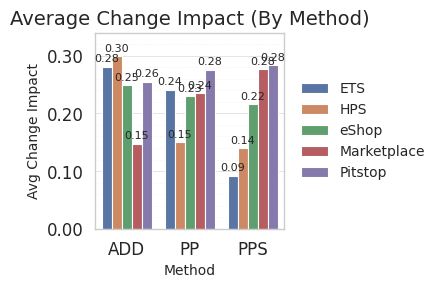

**Average Change Impact — By Method (Aggregated)**

App,ETS,HPS,Marketplace,Pitstop,eShop
Method,,,,,
ADD,0.281,0.299,0.147,0.255,0.249
PP,0.241,0.150,0.235,0.276,0.230
PPS,0.092,0.140,0.277,0.284,0.216


\begin{tabular}{lrrrrr}
\toprule
App & ETS & HPS & Marketplace & Pitstop & eShop \\
Method &  &  &  &  &  \\
\midrule
ADD & 0.281 & 0.299 & 0.147 & 0.255 & 0.249 \\
PP & 0.241 & 0.150 & 0.235 & 0.276 & 0.230 \\
PPS & 0.092 & 0.140 & 0.277 & 0.284 & 0.216 \\
\bottomrule
\end{tabular}



### By App

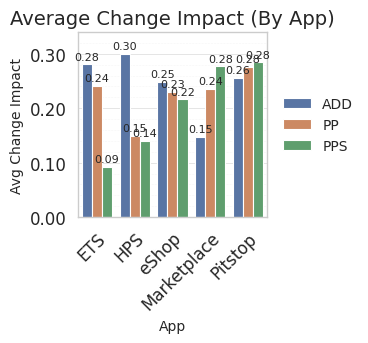

**Average Change Impact — By App (Aggregated)**

Method,ADD,PP,PPS
App,,,
ETS,0.281,0.241,0.092
HPS,0.299,0.150,0.140
Marketplace,0.147,0.235,0.277
Pitstop,0.255,0.276,0.284
eShop,0.249,0.230,0.216


\begin{tabular}{lrrr}
\toprule
Method & ADD & PP & PPS \\
App &  &  &  \\
\midrule
ETS & 0.281 & 0.241 & 0.092 \\
HPS & 0.299 & 0.150 & 0.140 \\
Marketplace & 0.147 & 0.235 & 0.277 \\
Pitstop & 0.255 & 0.276 & 0.284 \\
eShop & 0.249 & 0.230 & 0.216 \\
\bottomrule
\end{tabular}



**Average Change Impact — Unaggregated**

,Method,App,Average Change Impact
0,ADD,ETS,0.281
1,ADD,HPS,0.299
2,ADD,eShop,0.249
3,ADD,Marketplace,0.147
4,ADD,Pitstop,0.255
5,PP,ETS,0.241
6,PP,HPS,0.150
7,PP,eShop,0.230
8,PP,Marketplace,0.235
9,PP,Pitstop,0.276


\begin{tabular}{lllr}
\toprule
 & Method & App & Average Change Impact \\
\midrule
0 & ADD & ETS & 0.281 \\
1 & ADD & HPS & 0.299 \\
2 & ADD & eShop & 0.249 \\
3 & ADD & Marketplace & 0.147 \\
4 & ADD & Pitstop & 0.255 \\
5 & PP & ETS & 0.241 \\
6 & PP & HPS & 0.150 \\
7 & PP & eShop & 0.230 \\
8 & PP & Marketplace & 0.235 \\
9 & PP & Pitstop & 0.276 \\
10 & PPS & ETS & 0.092 \\
11 & PPS & HPS & 0.140 \\
12 & PPS & eShop & 0.216 \\
13 & PPS & Marketplace & 0.277 \\
14 & PPS & Pitstop & 0.284 \\
\bottomrule
\end{tabular}



## Node Recall, Precision, F1

### By Method

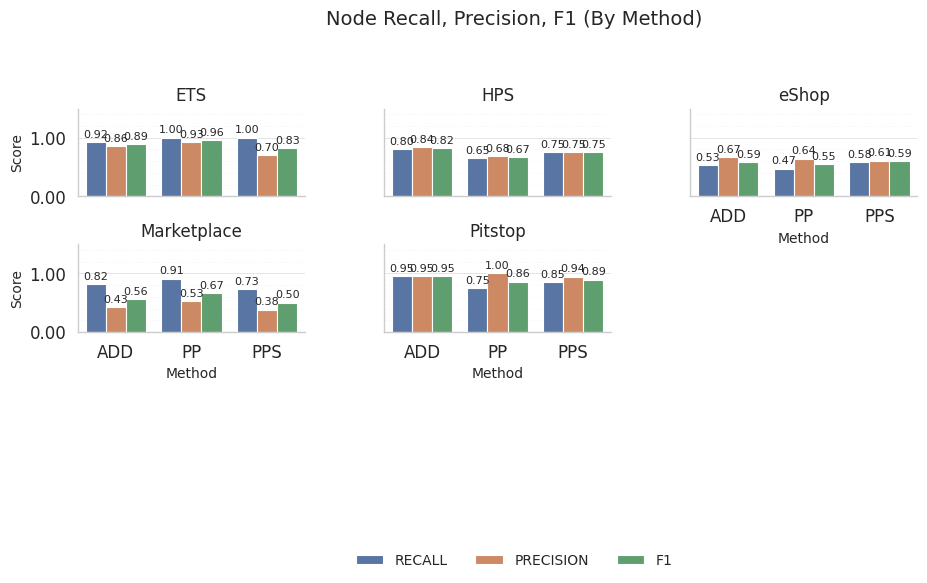

**Node Recall, Precision, F1 — By Method (Aggregated)**

RECALL                                  PRECISION         \
app_label    ETS   HPS Marketplace Pitstop  eShop       ETS    HPS   
Method                                                               
ADD        0.923  0.80       0.818    0.95  0.526     0.857  0.842   
PP         1.000  0.65       0.909    0.75  0.474     0.929  0.684   
PPS        1.000  0.75       0.727    0.85  0.579     0.703  0.750   

                                         F1                                    
app_label Marketplace Pitstop  eShop    ETS    HPS Marketplace Pitstop  eShop  
Method                                                                         
ADD             0.429   0.950  0.667  0.889  0.821       0.562   0.950  0.588  
PP              0.526   1.000  0.643  0.963  0.667       0.667   0.857  0.545  
PPS             0.381   0.944  0.611  0.825  0.750       0.500   0.895  0.595

\begin{tabular}{lrrrrrrrrrrrrrrr}
\toprule
 & \multicolumn{5}{r}{RECALL} & \multicolumn{5}{r}{PRECISION} & \multicolumn{5}{r}{F1} \\
app_label & ETS & HPS & Marketplace & Pitstop & eShop & ETS & HPS & Marketplace & Pitstop & eShop & ETS & HPS & Marketplace & Pitstop & eShop \\
Method &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
ADD & 0.923 & 0.800 & 0.818 & 0.950 & 0.526 & 0.857 & 0.842 & 0.429 & 0.950 & 0.667 & 0.889 & 0.821 & 0.562 & 0.950 & 0.588 \\
PP & 1.000 & 0.650 & 0.909 & 0.750 & 0.474 & 0.929 & 0.684 & 0.526 & 1.000 & 0.643 & 0.963 & 0.667 & 0.667 & 0.857 & 0.545 \\
PPS & 1.000 & 0.750 & 0.727 & 0.850 & 0.579 & 0.703 & 0.750 & 0.381 & 0.944 & 0.611 & 0.825 & 0.750 & 0.500 & 0.895 & 0.595 \\
\bottomrule
\end{tabular}



### By App

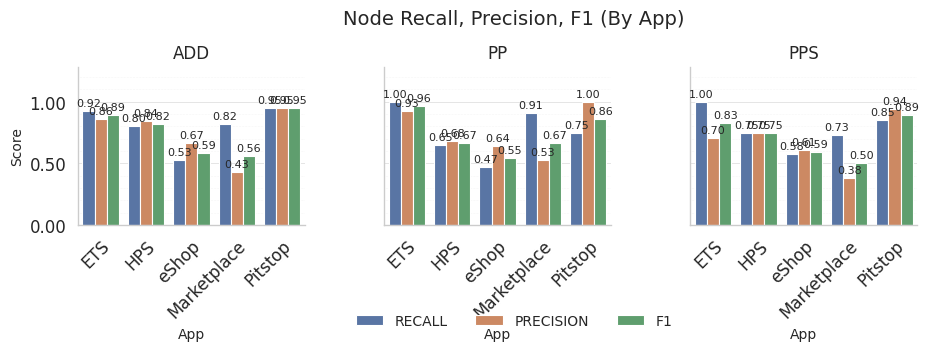

**Node Recall, Precision, F1 — By App (Aggregated)**

RECALL               PRECISION                   F1              
method_label    ADD     PP    PPS       ADD     PP    PPS    ADD     PP    PPS
App                                                                           
ETS           0.923  1.000  1.000     0.857  0.929  0.703  0.889  0.963  0.825
HPS           0.800  0.650  0.750     0.842  0.684  0.750  0.821  0.667  0.750
Marketplace   0.818  0.909  0.727     0.429  0.526  0.381  0.562  0.667  0.500
Pitstop       0.950  0.750  0.850     0.950  1.000  0.944  0.950  0.857  0.895
eShop         0.526  0.474  0.579     0.667  0.643  0.611  0.588  0.545  0.595

\begin{tabular}{lrrrrrrrrr}
\toprule
 & \multicolumn{3}{r}{RECALL} & \multicolumn{3}{r}{PRECISION} & \multicolumn{3}{r}{F1} \\
method_label & ADD & PP & PPS & ADD & PP & PPS & ADD & PP & PPS \\
App &  &  &  &  &  &  &  &  &  \\
\midrule
ETS & 0.923 & 1.000 & 1.000 & 0.857 & 0.929 & 0.703 & 0.889 & 0.963 & 0.825 \\
HPS & 0.800 & 0.650 & 0.750 & 0.842 & 0.684 & 0.750 & 0.821 & 0.667 & 0.750 \\
Marketplace & 0.818 & 0.909 & 0.727 & 0.429 & 0.526 & 0.381 & 0.562 & 0.667 & 0.500 \\
Pitstop & 0.950 & 0.750 & 0.850 & 0.950 & 1.000 & 0.944 & 0.950 & 0.857 & 0.895 \\
eShop & 0.526 & 0.474 & 0.579 & 0.667 & 0.643 & 0.611 & 0.588 & 0.545 & 0.595 \\
\bottomrule
\end{tabular}



**Node Recall, Precision, F1 — Unaggregated**

,Method,App,RECALL,PRECISION,F1
0,ADD,ETS,0.923,0.857,0.889
1,ADD,HPS,0.800,0.842,0.821
2,ADD,eShop,0.526,0.667,0.588
3,ADD,Marketplace,0.818,0.429,0.562
4,ADD,Pitstop,0.950,0.950,0.950
5,PP,ETS,1.000,0.929,0.963
6,PP,HPS,0.650,0.684,0.667
7,PP,eShop,0.474,0.643,0.545
8,PP,Marketplace,0.909,0.526,0.667
9,PP,Pitstop,0.750,1.000,0.857


\begin{tabular}{lllrrr}
\toprule
 & Method & App & RECALL & PRECISION & F1 \\
\midrule
0 & ADD & ETS & 0.923 & 0.857 & 0.889 \\
1 & ADD & HPS & 0.800 & 0.842 & 0.821 \\
2 & ADD & eShop & 0.526 & 0.667 & 0.588 \\
3 & ADD & Marketplace & 0.818 & 0.429 & 0.562 \\
4 & ADD & Pitstop & 0.950 & 0.950 & 0.950 \\
5 & PP & ETS & 1.000 & 0.929 & 0.963 \\
6 & PP & HPS & 0.650 & 0.684 & 0.667 \\
7 & PP & eShop & 0.474 & 0.643 & 0.545 \\
8 & PP & Marketplace & 0.909 & 0.526 & 0.667 \\
9 & PP & Pitstop & 0.750 & 1.000 & 0.857 \\
10 & PPS & ETS & 1.000 & 0.703 & 0.825 \\
11 & PPS & HPS & 0.750 & 0.750 & 0.750 \\
12 & PPS & eShop & 0.579 & 0.611 & 0.595 \\
13 & PPS & Marketplace & 0.727 & 0.381 & 0.500 \\
14 & PPS & Pitstop & 0.850 & 0.944 & 0.895 \\
\bottomrule
\end{tabular}



## Edge Recall, Precision, F1

### By Method

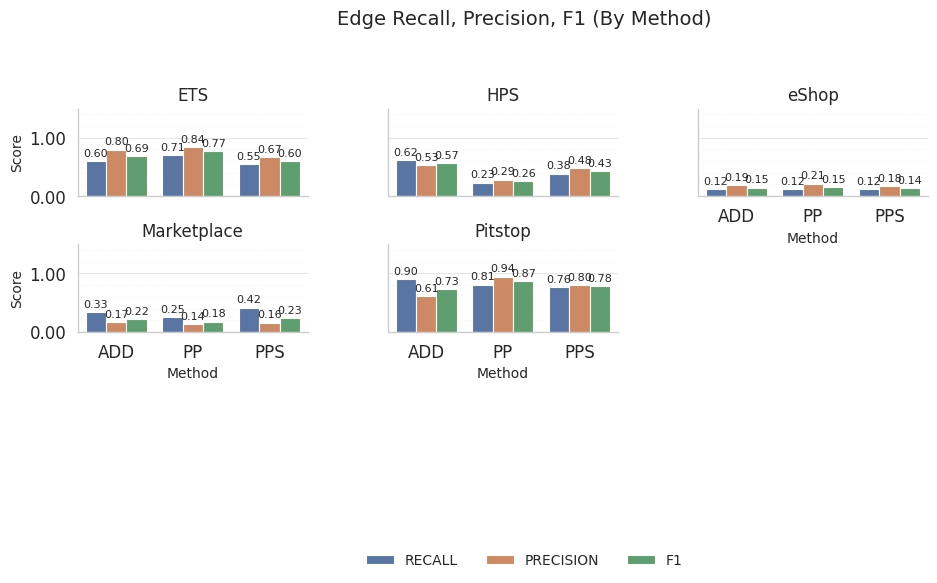

**Edge Recall, Precision, F1 — By Method (Aggregated)**

RECALL                                  PRECISION         \
app_label    ETS    HPS Marketplace Pitstop eShop       ETS    HPS   
Method                                                               
ADD        0.603  0.615       0.333   0.905  0.12     0.795  0.533   
PP         0.707  0.231       0.250   0.810  0.12     0.837  0.286   
PPS        0.552  0.385       0.417   0.762  0.12     0.667  0.476   

                                         F1                                    
app_label Marketplace Pitstop  eShop    ETS    HPS Marketplace Pitstop  eShop  
Method                                                                         
ADD             0.167   0.613  0.188  0.686  0.571       0.222   0.731  0.146  
PP              0.136   0.944  0.214  0.766  0.255       0.176   0.872  0.154  
PPS             0.161   0.800  0.176  0.604  0.426       0.233   0.780  0.143

\begin{tabular}{lrrrrrrrrrrrrrrr}
\toprule
 & \multicolumn{5}{r}{RECALL} & \multicolumn{5}{r}{PRECISION} & \multicolumn{5}{r}{F1} \\
app_label & ETS & HPS & Marketplace & Pitstop & eShop & ETS & HPS & Marketplace & Pitstop & eShop & ETS & HPS & Marketplace & Pitstop & eShop \\
Method &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
ADD & 0.603 & 0.615 & 0.333 & 0.905 & 0.120 & 0.795 & 0.533 & 0.167 & 0.613 & 0.188 & 0.686 & 0.571 & 0.222 & 0.731 & 0.146 \\
PP & 0.707 & 0.231 & 0.250 & 0.810 & 0.120 & 0.837 & 0.286 & 0.136 & 0.944 & 0.214 & 0.766 & 0.255 & 0.176 & 0.872 & 0.154 \\
PPS & 0.552 & 0.385 & 0.417 & 0.762 & 0.120 & 0.667 & 0.476 & 0.161 & 0.800 & 0.176 & 0.604 & 0.426 & 0.233 & 0.780 & 0.143 \\
\bottomrule
\end{tabular}



### By App

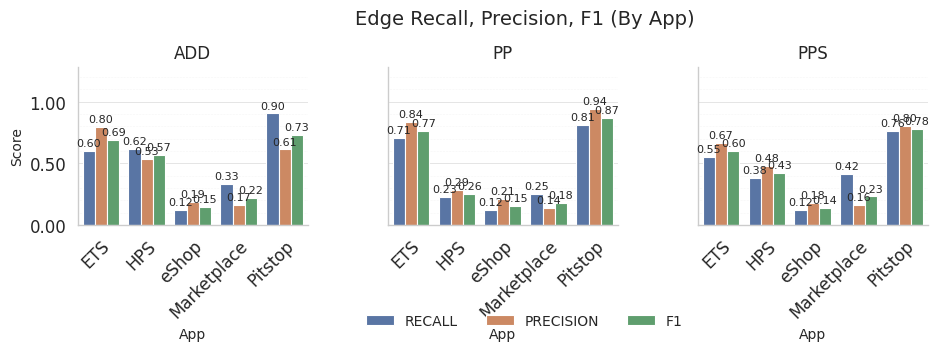

**Edge Recall, Precision, F1 — By App (Aggregated)**

RECALL               PRECISION                   F1              
method_label    ADD     PP    PPS       ADD     PP    PPS    ADD     PP    PPS
App                                                                           
ETS           0.603  0.707  0.552     0.795  0.837  0.667  0.686  0.766  0.604
HPS           0.615  0.231  0.385     0.533  0.286  0.476  0.571  0.255  0.426
Marketplace   0.333  0.250  0.417     0.167  0.136  0.161  0.222  0.176  0.233
Pitstop       0.905  0.810  0.762     0.613  0.944  0.800  0.731  0.872  0.780
eShop         0.120  0.120  0.120     0.188  0.214  0.176  0.146  0.154  0.143

\begin{tabular}{lrrrrrrrrr}
\toprule
 & \multicolumn{3}{r}{RECALL} & \multicolumn{3}{r}{PRECISION} & \multicolumn{3}{r}{F1} \\
method_label & ADD & PP & PPS & ADD & PP & PPS & ADD & PP & PPS \\
App &  &  &  &  &  &  &  &  &  \\
\midrule
ETS & 0.603 & 0.707 & 0.552 & 0.795 & 0.837 & 0.667 & 0.686 & 0.766 & 0.604 \\
HPS & 0.615 & 0.231 & 0.385 & 0.533 & 0.286 & 0.476 & 0.571 & 0.255 & 0.426 \\
Marketplace & 0.333 & 0.250 & 0.417 & 0.167 & 0.136 & 0.161 & 0.222 & 0.176 & 0.233 \\
Pitstop & 0.905 & 0.810 & 0.762 & 0.613 & 0.944 & 0.800 & 0.731 & 0.872 & 0.780 \\
eShop & 0.120 & 0.120 & 0.120 & 0.188 & 0.214 & 0.176 & 0.146 & 0.154 & 0.143 \\
\bottomrule
\end{tabular}



**Edge Recall, Precision, F1 — Unaggregated**

,Method,App,RECALL,PRECISION,F1
0,ADD,ETS,0.603,0.795,0.686
1,ADD,HPS,0.615,0.533,0.571
2,ADD,eShop,0.120,0.188,0.146
3,ADD,Marketplace,0.333,0.167,0.222
4,ADD,Pitstop,0.905,0.613,0.731
5,PP,ETS,0.707,0.837,0.766
6,PP,HPS,0.231,0.286,0.255
7,PP,eShop,0.120,0.214,0.154
8,PP,Marketplace,0.250,0.136,0.176
9,PP,Pitstop,0.810,0.944,0.872


\begin{tabular}{lllrrr}
\toprule
 & Method & App & RECALL & PRECISION & F1 \\
\midrule
0 & ADD & ETS & 0.603 & 0.795 & 0.686 \\
1 & ADD & HPS & 0.615 & 0.533 & 0.571 \\
2 & ADD & eShop & 0.120 & 0.188 & 0.146 \\
3 & ADD & Marketplace & 0.333 & 0.167 & 0.222 \\
4 & ADD & Pitstop & 0.905 & 0.613 & 0.731 \\
5 & PP & ETS & 0.707 & 0.837 & 0.766 \\
6 & PP & HPS & 0.231 & 0.286 & 0.255 \\
7 & PP & eShop & 0.120 & 0.214 & 0.154 \\
8 & PP & Marketplace & 0.250 & 0.136 & 0.176 \\
9 & PP & Pitstop & 0.810 & 0.944 & 0.872 \\
10 & PPS & ETS & 0.552 & 0.667 & 0.604 \\
11 & PPS & HPS & 0.385 & 0.476 & 0.426 \\
12 & PPS & eShop & 0.120 & 0.176 & 0.143 \\
13 & PPS & Marketplace & 0.417 & 0.161 & 0.233 \\
14 & PPS & Pitstop & 0.762 & 0.800 & 0.780 \\
\bottomrule
\end{tabular}



In [4]:
setup_style()
for section in METRIC_SECTIONS:
    render_section(df, section, SHORT_LABELS)

## Presentation Charts

### Change Impact — by app

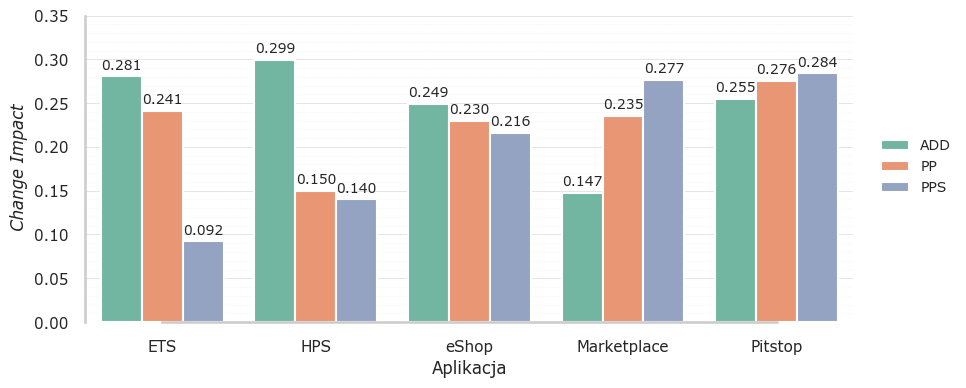

### Change Impact — by method (mean over apps)

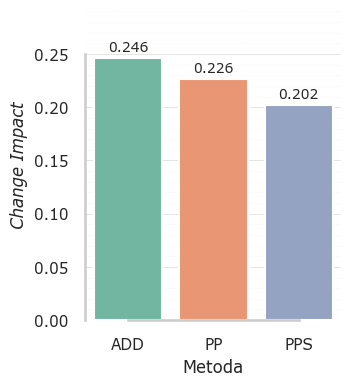

### Maintainability Index — by app

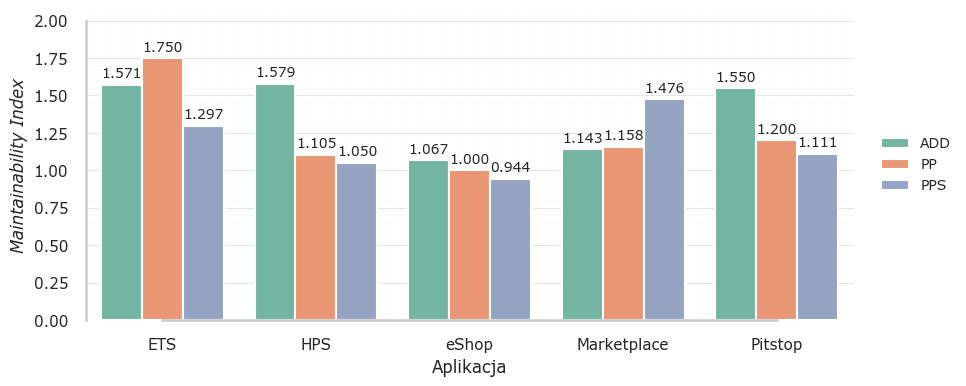

### Maintainability Index — by method (mean over apps)

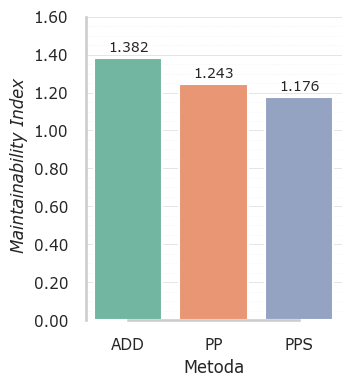

### F1 (usługi) — by app

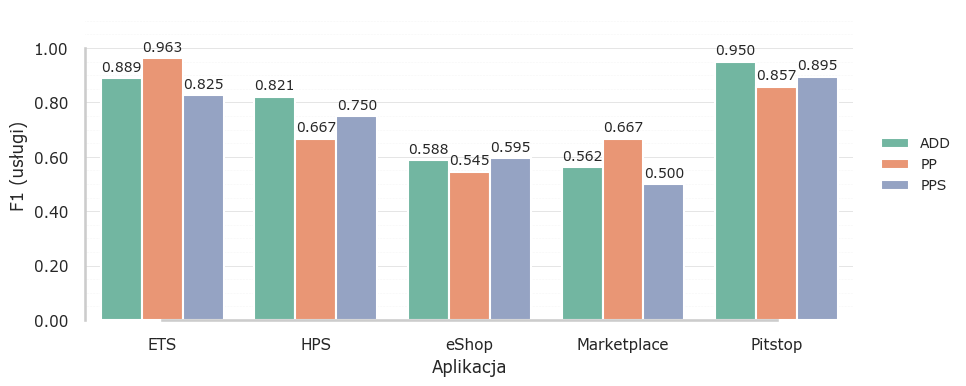

### F1 (usługi) — by method (mean over apps)

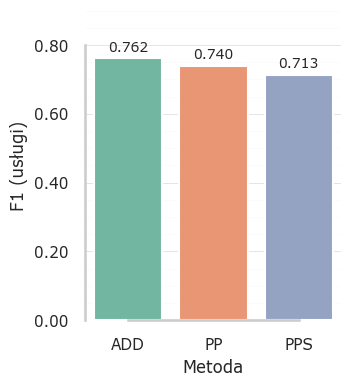

### F1 (krawędzie) — by app

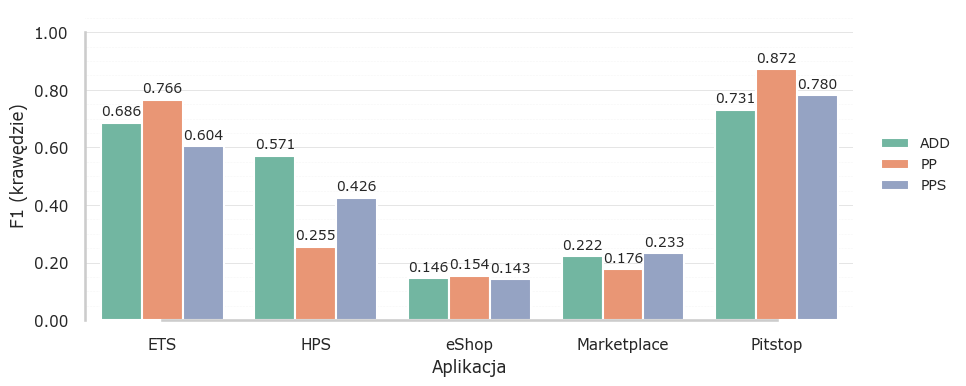

### F1 (krawędzie) — by method (mean over apps)

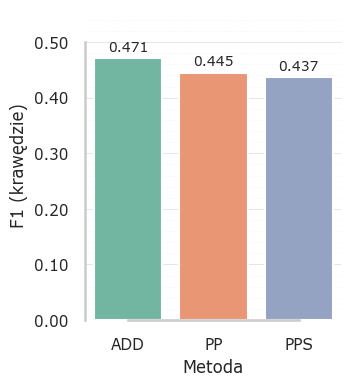

Exported 16 files to /home/tomek/pbad/PBAD/code/notebooks/output/presentation
  change_impact_by_app.png
  change_impact_by_app.pdf
  change_impact_by_method_mean.png
  change_impact_by_method_mean.pdf
  maintainability_index_by_app.png
  maintainability_index_by_app.pdf
  maintainability_index_by_method_mean.png
  maintainability_index_by_method_mean.pdf
  node_f1_by_app.png
  node_f1_by_app.pdf
  node_f1_by_method_mean.png
  node_f1_by_method_mean.pdf
  edge_f1_by_app.png
  edge_f1_by_app.pdf
  edge_f1_by_method_mean.png
  edge_f1_by_method_mean.pdf


In [5]:
from pathlib import Path

from _experiment_viz import (
    export_presentation_charts,
    render_presentation_charts,
    setup_presentation_style,
)
from IPython.display import Markdown, display

setup_presentation_style()
display(Markdown("## Presentation Charts"))
render_presentation_charts(df, SHORT_LABELS)

presentation_dir = Path("output/presentation")
saved = export_presentation_charts(df, SHORT_LABELS, presentation_dir)
print(f"Exported {len(saved)} files to {presentation_dir.resolve()}")
for path in saved:
    print(f"  {path.name}")

## Paper Charts

### Change Impact
(mniej = lepiej) — by app

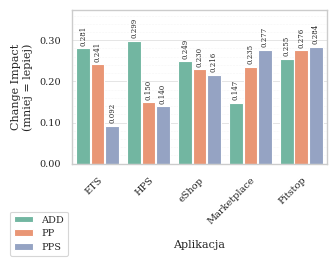

### Change Impact
(mniej = lepiej) — by method (mean over apps)

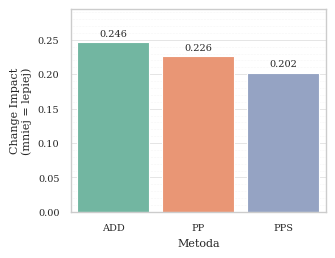

### Dependency degree
(mniej = lepiej) — by app

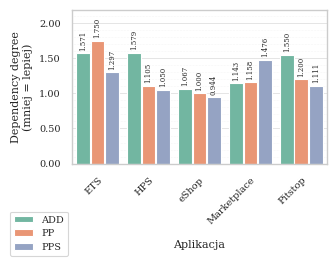

### Dependency degree
(mniej = lepiej) — by method (mean over apps)

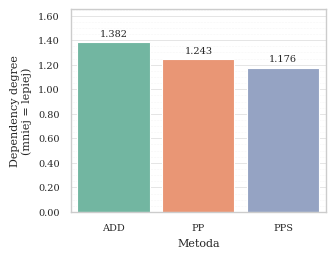

### F1 (usługi)
(więcej = lepiej) — by app

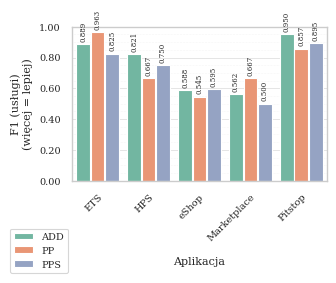

### F1 (usługi)
(więcej = lepiej) — by method (mean over apps)

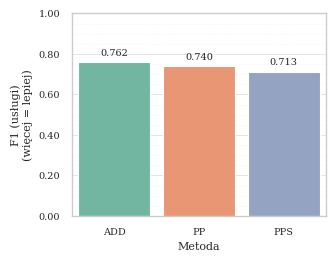

### F1 (krawędzie)
(więcej = lepiej) — by app

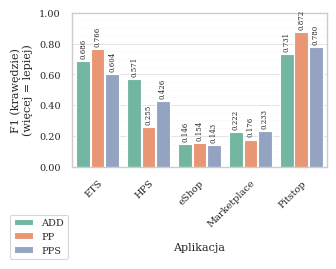

### F1 (krawędzie)
(więcej = lepiej) — by method (mean over apps)

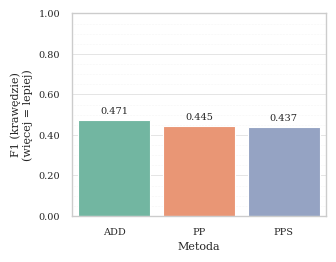

Exported 16 files
  PDF: /home/tomek/pbad/PBAD/tex/assets
  PNG: /home/tomek/pbad/PBAD/code/notebooks/output/paper
  change_impact_by_app.pdf
  change_impact_by_app.png
  change_impact_by_method_mean.pdf
  change_impact_by_method_mean.png
  dependency_degree_by_app.pdf
  dependency_degree_by_app.png
  dependency_degree_by_method_mean.pdf
  dependency_degree_by_method_mean.png
  node_f1_by_app.pdf
  node_f1_by_app.png
  node_f1_by_method_mean.pdf
  node_f1_by_method_mean.png
  edge_f1_by_app.pdf
  edge_f1_by_app.png
  edge_f1_by_method_mean.pdf
  edge_f1_by_method_mean.png


In [6]:
from pathlib import Path

from _experiment_viz import (
    export_paper_charts,
    render_paper_charts,
    setup_paper_chart_style,
)
from IPython.display import Markdown, display

setup_paper_chart_style()
display(Markdown("## Paper Charts"))
render_paper_charts(df, SHORT_LABELS)

paper_pdf_dir = Path("../../tex/assets")
paper_png_dir = Path("output/paper")
saved = export_paper_charts(df, SHORT_LABELS, paper_pdf_dir, paper_png_dir)
print(f"Exported {len(saved)} files")
print(f"  PDF: {paper_pdf_dir.resolve()}")
print(f"  PNG: {paper_png_dir.resolve()}")
for path in saved:
    print(f"  {path.name}")